In [1]:
import duckdb
import polars as pl
from life_event_metadata.plotting import make_gantt_chart
from life_event_metadata.utils import wide_print

In [2]:
con = duckdb.connect("../data/event_datasets.duckdb", read_only=True)

## Explore datasets we have on RA but are not in the KG

In [3]:
datasets_9424 = pl.read_csv("../data/Datasets 9424.csv")
datasets_9424 = datasets_9424.filter(~pl.col("Type bestand").is_in(["Upload / import bestand"]))

In [4]:
datasets = con.sql("select alt_title from kg_datasets").pl()
datasets.head()

alt_title
str
"""EXAMVOJJJJINT"""
"""CCO"""
"""VRLGBAADRESOBJECTBUS"""
"""ZORGMVTAB"""
"""ARBBUITLANDMNDBEDRAGBUS"""


In [5]:
datasets_9424 = datasets_9424.with_columns(
    in_query_result=pl.col("Bestandsnaam").is_in(datasets["alt_title"].to_list())
)

In [6]:
datasets_9424.describe()

statistic,Bestandsnaam,Bestandsonderwerp,Type bestand,Status,in_query_result
str,str,str,str,str,f64
"""count""","""55""","""55""","""55""","""55""",55.0
"""null_count""","""0""","""0""","""0""","""0""",0.0
"""mean""",null,null,null,null,0.763636
"""std""",null,null,null,null,null
"""min""","""BURENNETWERKTAB""","""CIMS""","""Catalogusbestand""","""Available""",0.0
"""25%""",null,null,null,null,null
"""50%""",null,null,null,null,null
"""75%""",null,null,null,null,null
"""max""","""ZVWZORGKOSTENTAB""","""ZORGKOSTEN""","""Maatwerkbestand""","""Rejected""",1.0


In [7]:
wide_print(datasets_9424.filter(~pl.col("in_query_result")), n_rows=-1)

shape: (13, 5)
┌────────────────────────┬──────────────────────┬──────────────────┬───────────┬─────────────────┐
│ Bestandsnaam           ┆ Bestandsonderwerp    ┆ Type bestand     ┆ Status    ┆ in_query_result │
│ ---                    ┆ ---                  ┆ ---              ┆ ---       ┆ ---             │
│ str                    ┆ str                  ┆ str              ┆ str       ┆ bool            │
╞════════════════════════╪══════════════════════╪══════════════════╪═══════════╪═════════════════╡
│ EIGENDOMTAB            ┆ EIGENDOMWOZ          ┆ Catalogusbestand ┆ Available ┆ false           │
│ EIGENDOMWOZBAGTAB      ┆ EIGENDOMWOZ          ┆ Catalogusbestand ┆ Available ┆ false           │
│ EIGENDOMWOZTAB         ┆ EIGENDOMWOZ          ┆ Catalogusbestand ┆ Available ┆ false           │
│ GBAPERSOONKTAB         ┆ GBAPERSOON           ┆ Catalogusbestand ┆ Available ┆ false           │
│ GBASCHEIDINGENMASSATAB ┆ GBAPARTNER           ┆ Catalogusbestand ┆ Available ┆ false        

From looking up manually, I found the following cases
- used elsewhere/not important for now
  - LISS, KINDEROPVANGLOCATIES
- **does not directly have RINPERSOON column, but other person identifier**
  - GBASCHEIDINGENMASSATAB (divorces), VEHTAB (wealth)
- homeownership
  - WOZ, EIGENDOMTAB, EIGENDOMWOZBAGTAB, EIGENDOMWOZTAB: related to home ownership. This might be important, but not all of these contain RINPERSOON. This is relational structure that we have not captured from the KG so far. Can it be captured in any way? some of these may have person identifiers, but not all (mapping object id -> object value)
- Not in the portal
  - GBAPERSOONKTAB, NCOTOOL, NIETVSLGTAB, VRLGBAPERSOONKTAB, VSLGTAB



## Data sets: topics, availability and breaks

Most common keyword sets

In [8]:
con.sql("DROP TABLE IF EXISTS keywords_and_datasets")
con.sql("""
    CREATE TEMP TABLE keywords_and_datasets AS (
    SELECT
        COUNT(DISTINCT alt_title) as n_datasets
        , keywords
    FROM kg_datasets
    GROUP BY keywords
    ORDER BY n_datasets DESC
)
""")

In [9]:
con.sql("""
    select * from keywords_and_datasets limit 10
""")

┌────────────┬─────────────────────────────────────────────────────────────────────────────────────┐
│ n_datasets │                                      keywords                                       │
│   int64    │                                      varchar[]                                      │
├────────────┼─────────────────────────────────────────────────────────────────────────────────────┤
│        125 │ [Arbeid en sociale zekerheid]                                                       │
│         64 │ [Gezondheid en welzijn]                                                             │
│         40 │ [Bevolking]                                                                         │
│         36 │ [Onderwijs]                                                                         │
│         22 │ [Arbeid en sociale zekerheid, Inkomen en bestedingen]                               │
│         18 │ [Inkomen en bestedingen]                                                    

### Dataset availability by keyword

In [10]:
n_datasets_min = 10  # min N datasets per keyword collection
truncate_left = "1990-12-31"
truncate_right = "2026-12-31"  # to avoid NULLs

In [11]:
con.sql("""DROP TABLE IF EXISTS temp_datasets""")
con.execute(
    f"""
CREATE TEMP table temp_datasets AS (
 SELECT d.*
     , GREATEST(DATE '{truncate_left}', LEAST(d.valid_from)) as clean_valid_from
     , COALESCE(d.valid_until, DATE '{truncate_right}') AS clean_valid_until
 FROM kg_datasets AS d
 WHERE d.keywords IN (
     SELECT keywords
     FROM keywords_and_datasets
     WHERE n_datasets >= ?
 )
 )
""",
    (n_datasets_min,),
)
con.sql("select alt_title, clean_valid_from, clean_valid_until from temp_datasets")

┌────────────────────────────┬──────────────────┬───────────────────┐
│         alt_title          │ clean_valid_from │ clean_valid_until │
│          varchar           │       date       │       date        │
├────────────────────────────┼──────────────────┼───────────────────┤
│ EXAMVOJJJJINT              │ 2006-10-01       │ 2008-10-01        │
│ VRLGBAADRESOBJECTBUS       │ 1995-01-01       │ 2018-07-01        │
│ ZORGMVTAB                  │ 2004-01-01       │ 2011-01-01        │
│ ARBBUITLANDMNDBEDRAGBUS    │ 2001-01-01       │ 2026-12-31        │
│ SRGPERSOONPWETBUS          │ 2017-01-01       │ 2019-01-01        │
│ EBWLZBUS                   │ 2015-01-01       │ 2026-12-31        │
│ STUDIEBEURSMNDBEDRAGBUS    │ 1999-01-01       │ 2026-12-31        │
│ DIPLOMAVAVOTAB             │ 2004-10-01       │ 2026-12-31        │
│ DOODOORZTAB                │ 2013-01-01       │ 2026-12-31        │
│ EBBARBZORGTAB              │ 2019-01-01       │ 2021-01-01        │
│       ·           

**Note: the `title_cte` assumes dataset type does not change with the breaks**

In [12]:
datasets_summarised = con.sql("""
    WITH dataset_cte AS (
        SELECT
            COUNT(DISTINCT dataset_id) AS n_datasets
            , MIN(clean_valid_from) AS first_available
            , MAX(clean_valid_until) AS last_available
            , list(DISTINCT(valid_until)) as breaks
            , alt_title
        FROM temp_datasets
        GROUP BY alt_title
    )
    , title_cte AS (
        SELECT alt_title, is_tijdstip_dataset, is_frequency_dataset, keywords
            , row_number() OVER  (PARTITION BY alt_title) as rowid
        FROM kg_datasets
    )
    SELECT
        alt_title
        , breaks
        , first_available
        , last_available
        , CASE
            WHEN is_tijdstip_dataset AND is_frequency_dataset THEN 'freq & tijdstip'
            WHEN is_tijdstip_dataset THEN 'tijdstip'
            ELSE 'frequency' END as dataset_type
        , keywords
    FROM dataset_cte
    INNER JOIN (
        SELECT * from title_cte
        WHERE rowid=1
    ) USING(alt_title)
    ORDER BY first_available DESC
""").pl()

In [13]:
datasets_summarised

alt_title,breaks,first_available,last_available,dataset_type,keywords
str,list[date],date,date,str,list[str]
"""WNE2024-II""",[null],2024-11-01,2026-12-31,"""tijdstip""","[""Arbeid en sociale zekerheid""]"
"""WNE2023-II""",[2024-05-01],2023-11-01,2024-05-01,"""tijdstip""","[""Arbeid en sociale zekerheid""]"
"""BIG_ANALYSEBESTAND""",[null],2023-01-02,2026-12-31,"""freq & tijdstip""","[""Gezondheid en welzijn""]"
"""EBBARBEIDZORGTAB""",[null],2023-01-01,2026-12-31,"""freq & tijdstip""","[""Arbeid en sociale zekerheid"", ""Gezondheid en welzijn""]"
"""WNE2022-II""",[2023-05-01],2022-11-01,2023-05-01,"""tijdstip""","[""Arbeid en sociale zekerheid"", ""Gezondheid en welzijn""]"
…,…,…,…,…,…
"""GBAKINDBUS""",[null],1994-10-01,2026-12-31,"""freq & tijdstip""","[""Bevolking""]"
"""CWITAB""",[2019-01-01],1990-12-31,2019-01-01,"""freq & tijdstip""","[""Arbeid en sociale zekerheid""]"
"""VRLGBAGEBOORTEGEMEENTETAB""",[null],1990-12-31,2026-12-31,"""frequency""","[""Bevolking""]"


In [14]:
datasets_summarised["keywords"].unique().to_list()

[['Arbeid en sociale zekerheid', 'Inkomen en bestedingen'],
 ['Veiligheid en recht'],
 ['Onderwijs'],
 ['Inkomen en bestedingen'],
 ['Gezondheid en welzijn'],
 ['Arbeid en sociale zekerheid'],
 ['Bevolking'],
 ['Arbeid en sociale zekerheid', 'Gezondheid en welzijn']]

In [15]:
dataset_categories = datasets_summarised["keywords"].unique().to_list()

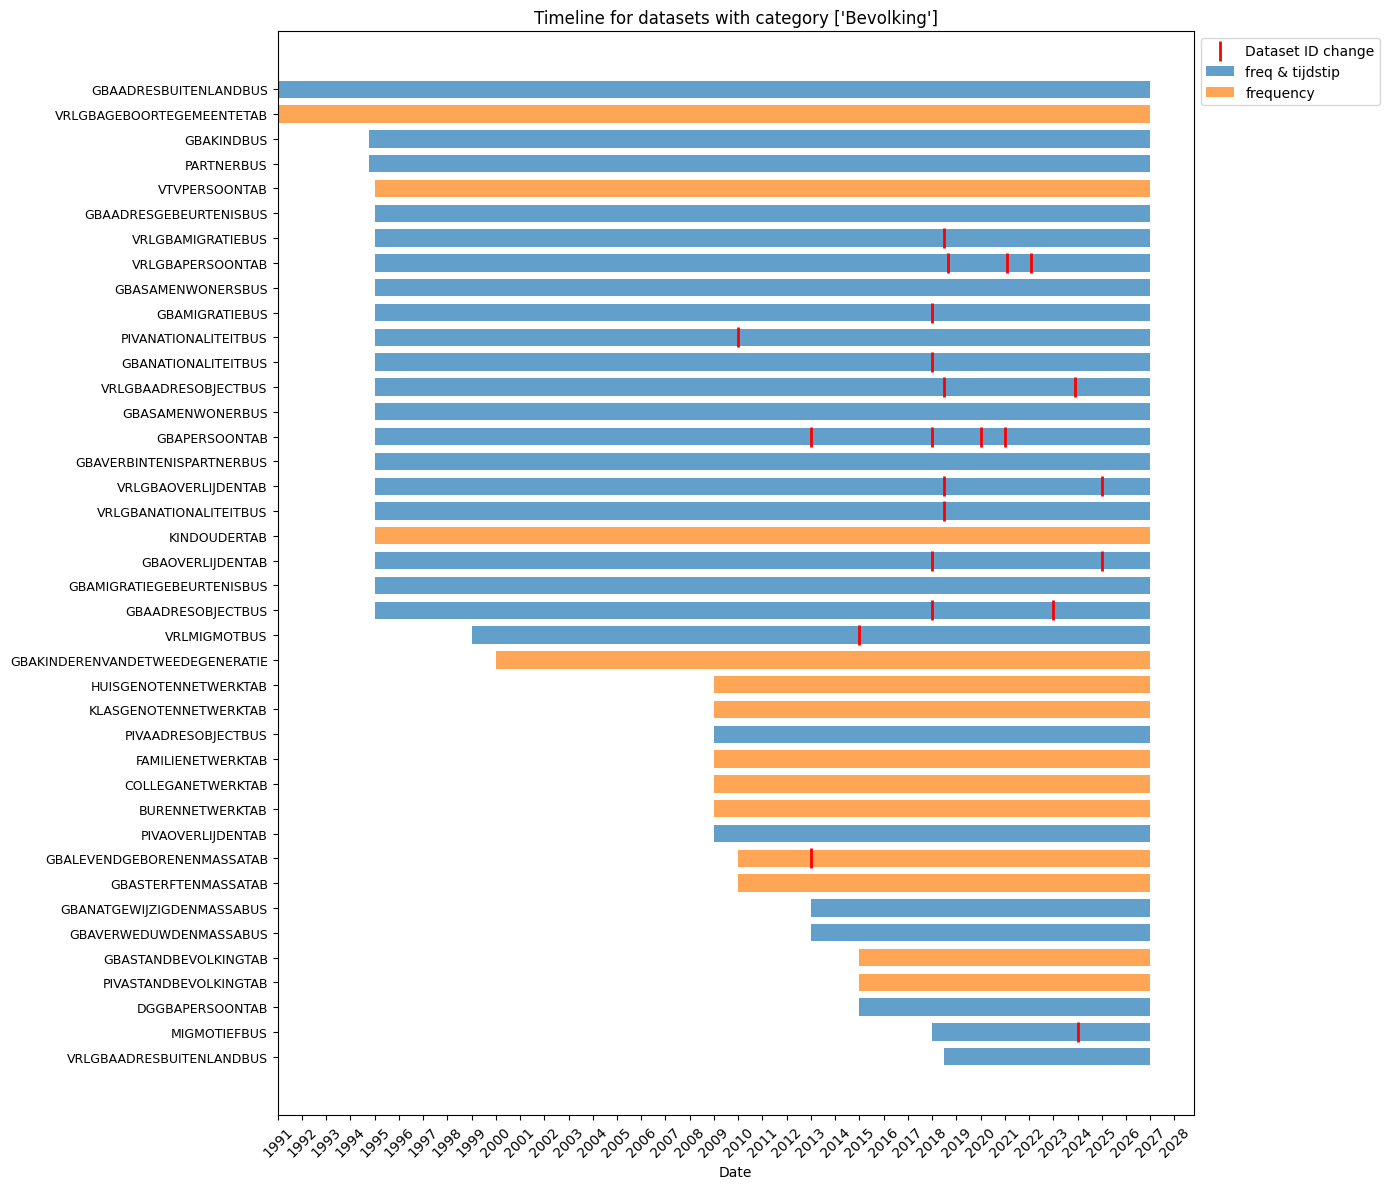

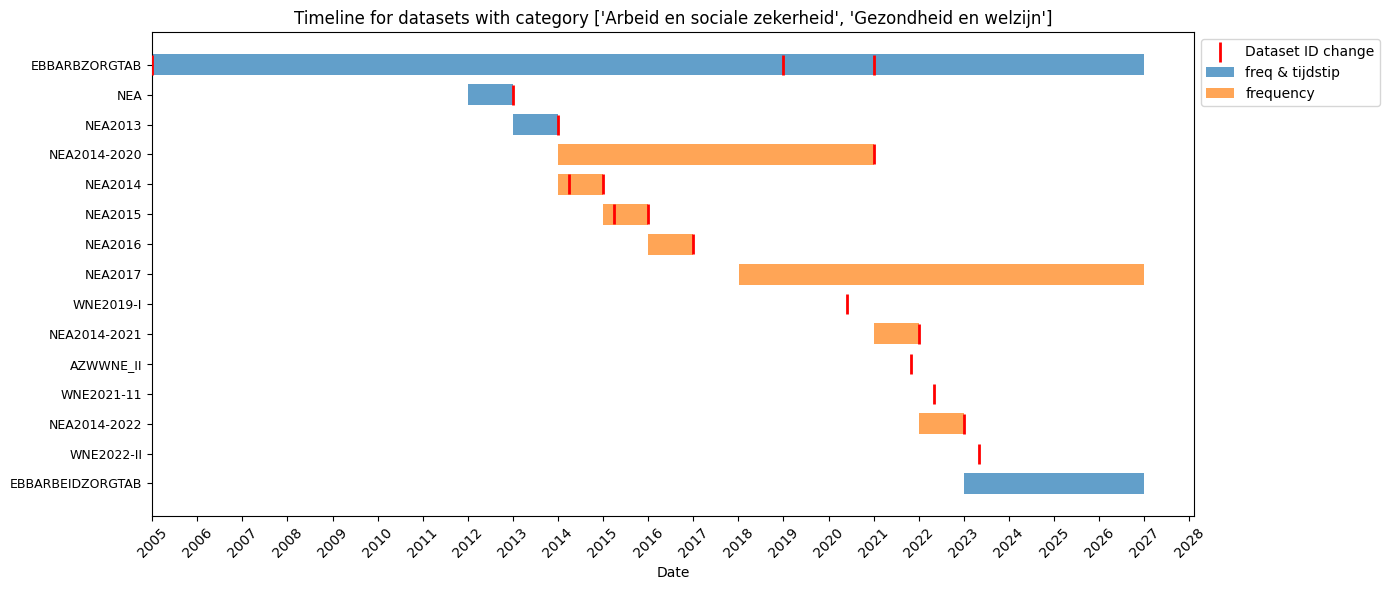

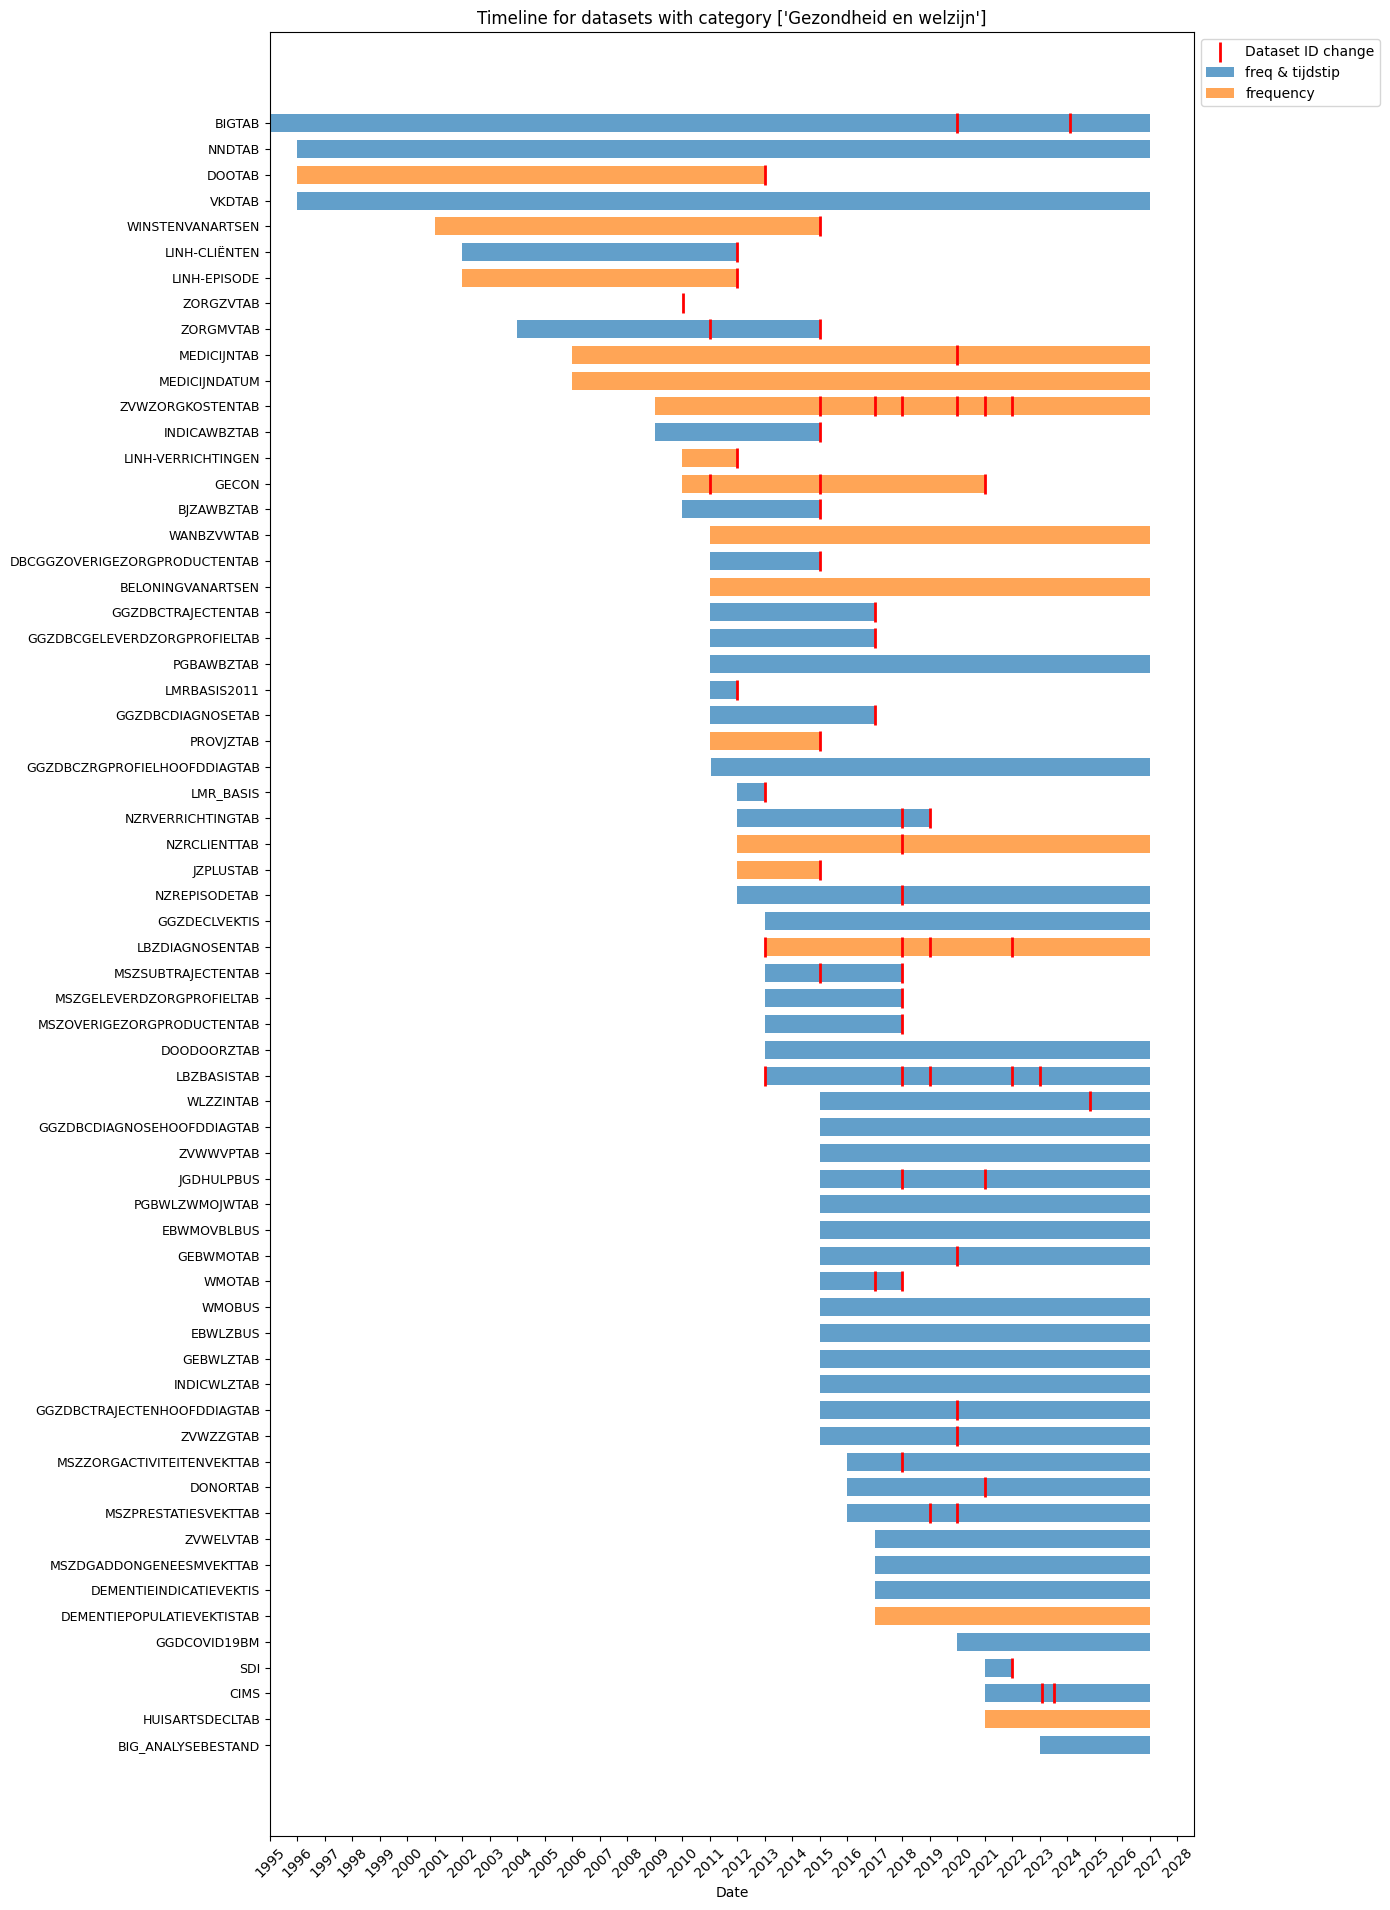

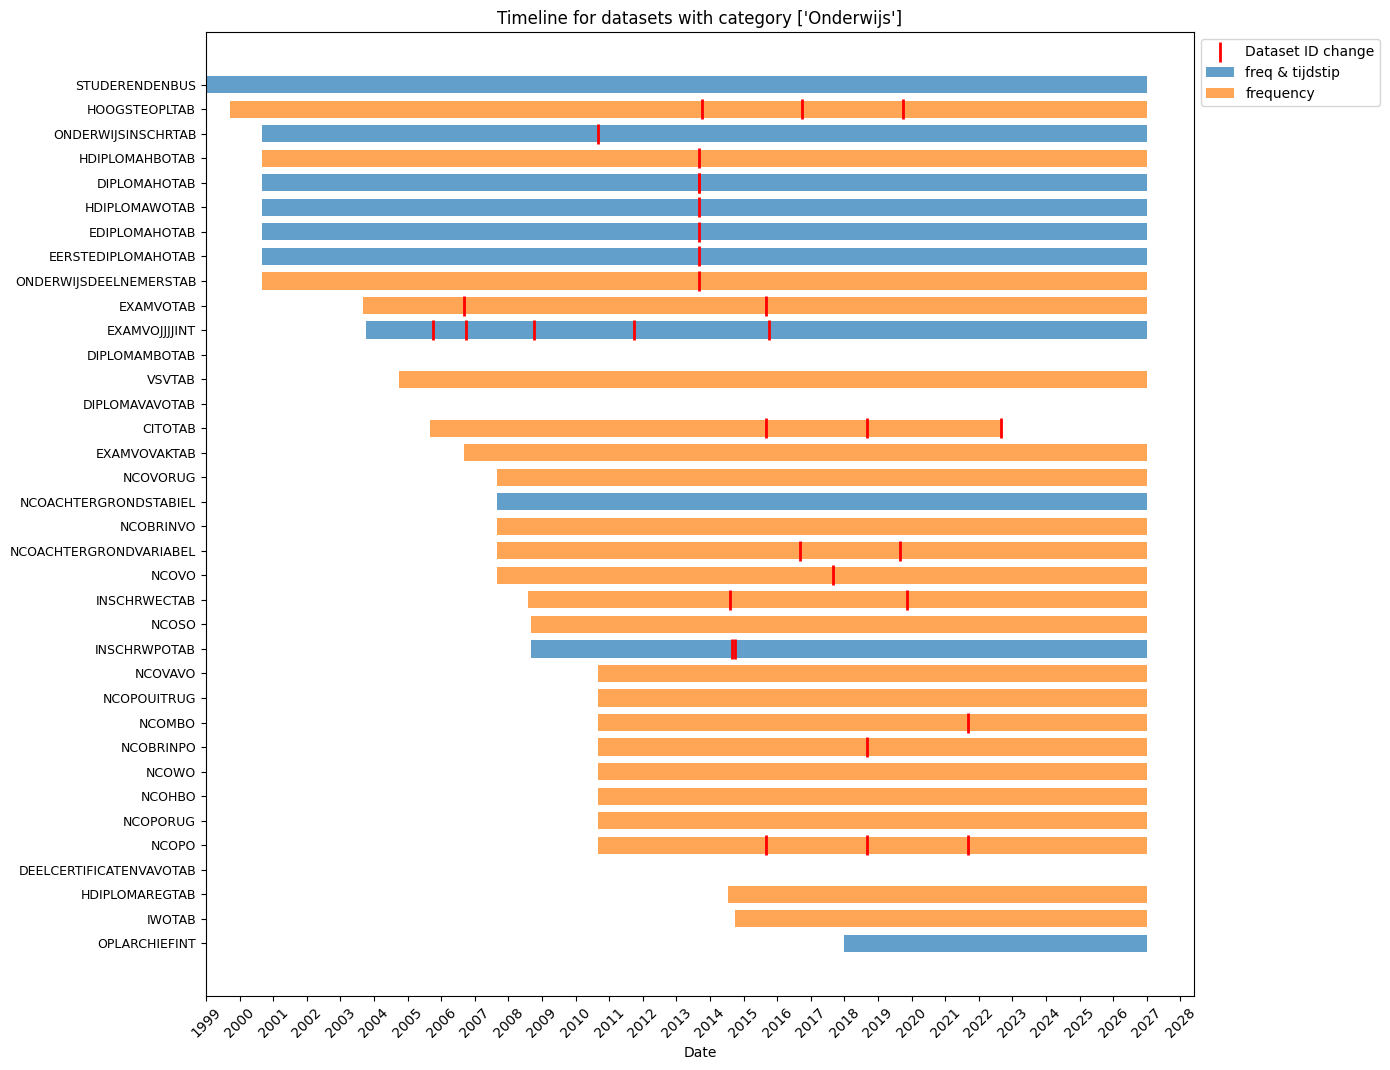

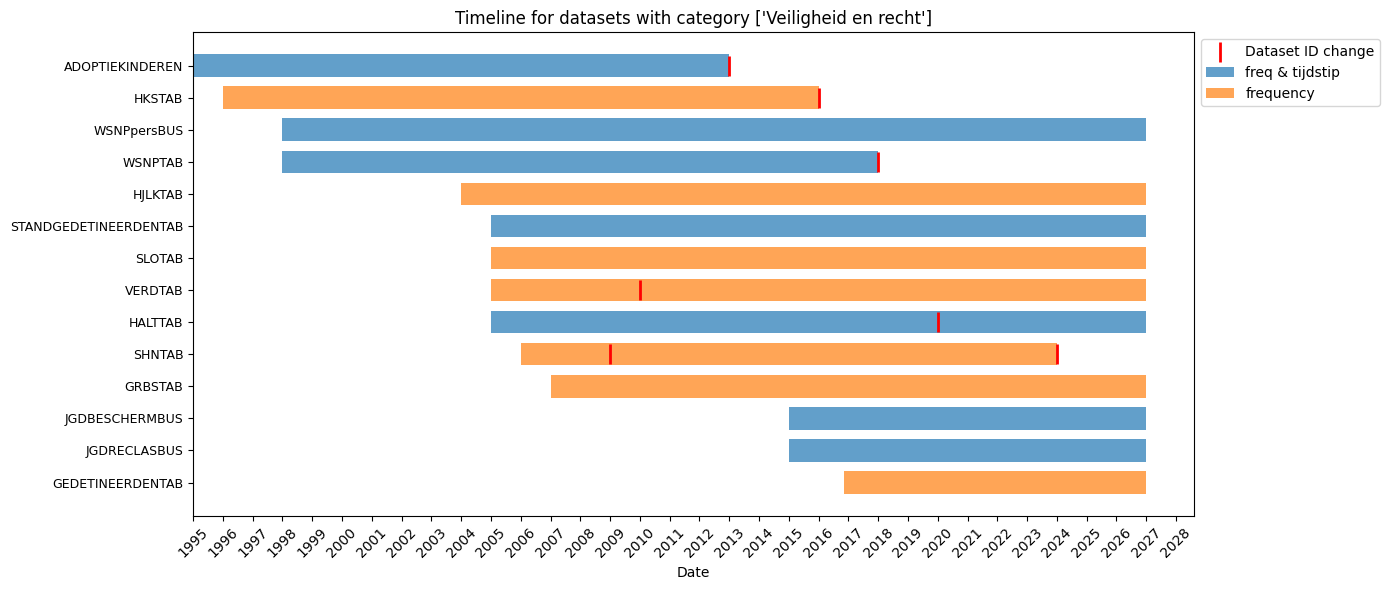

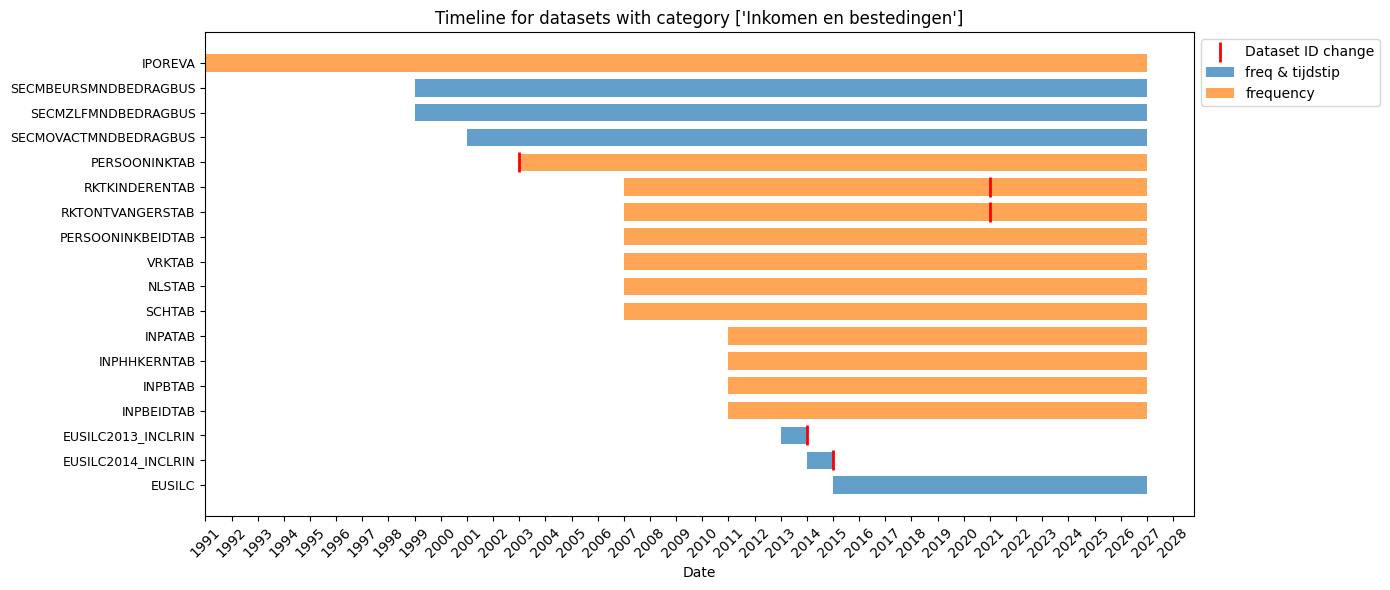

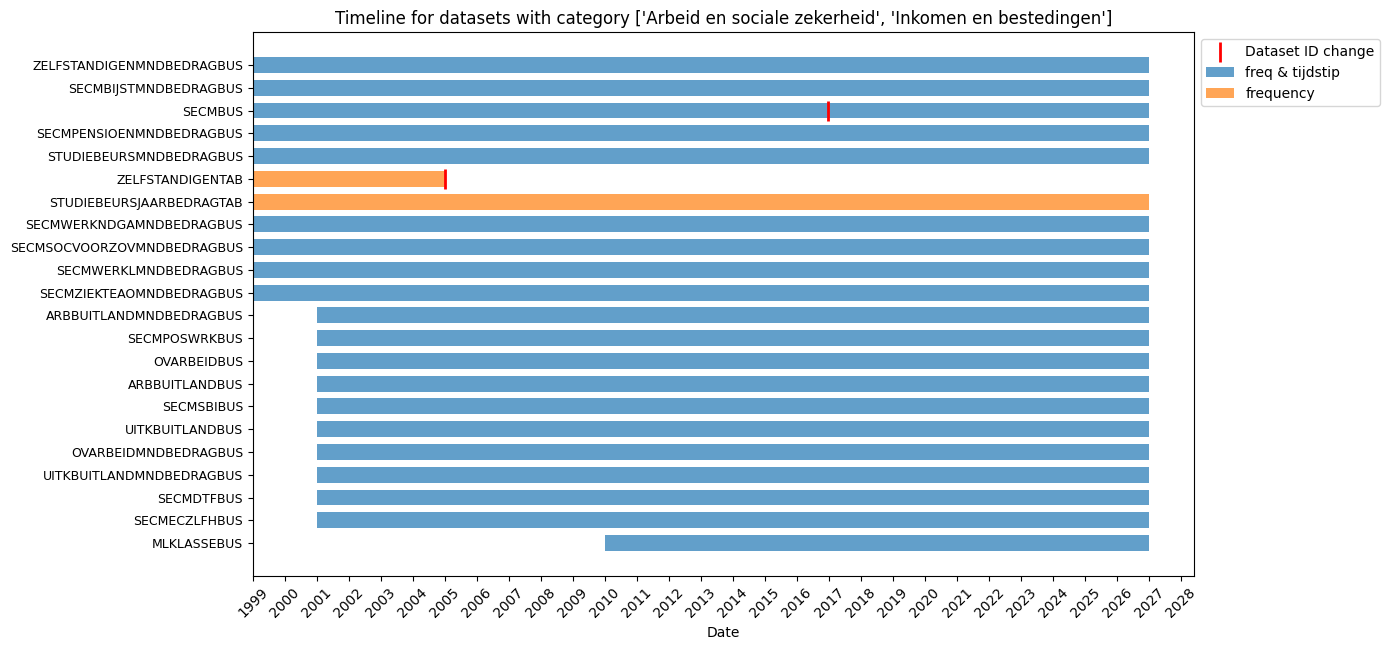

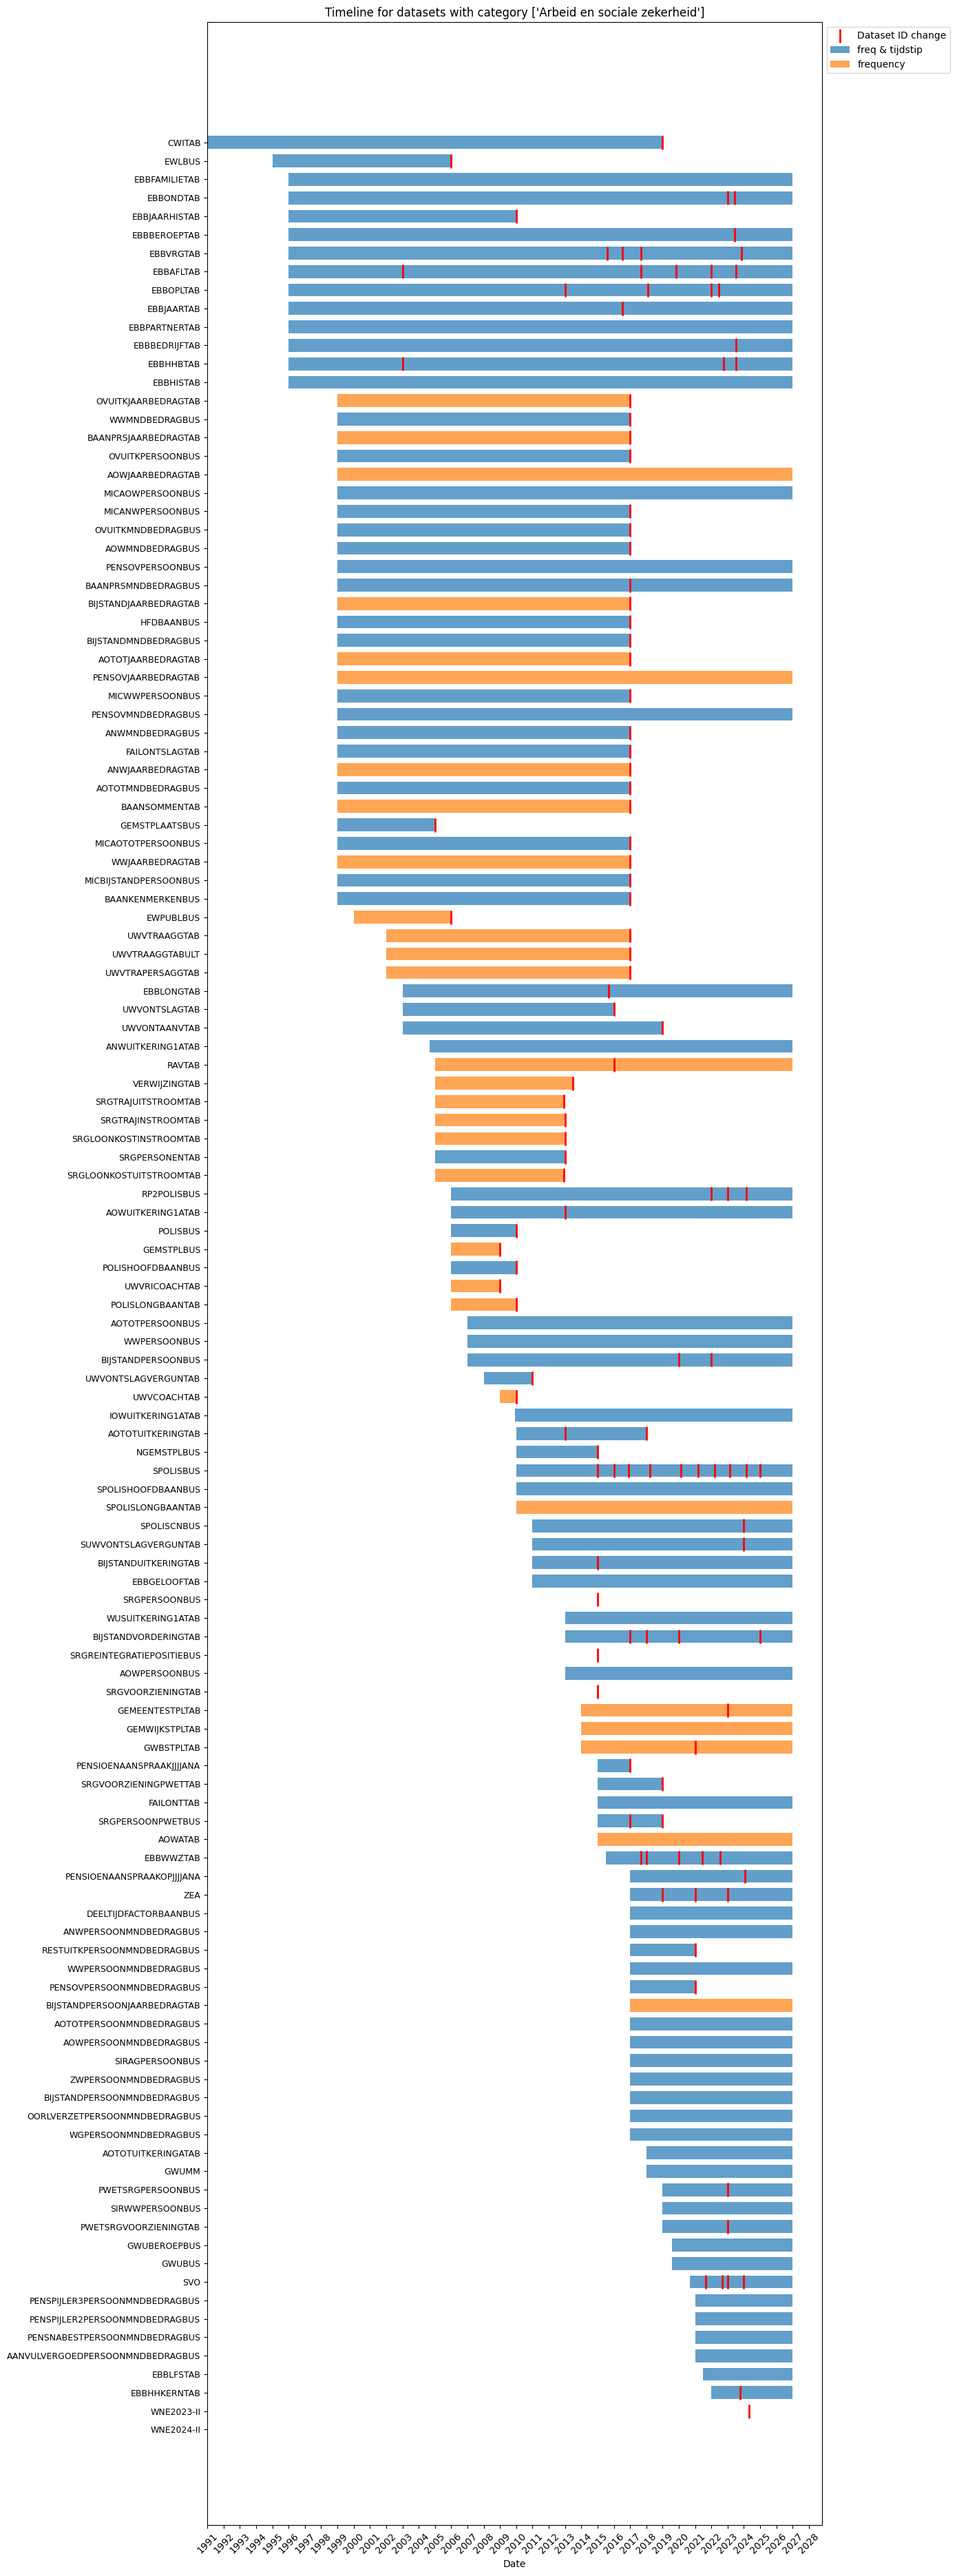

In [29]:
category_mapping = {
    "freq & tijdstip": "#1f77b4",  # Blue
    "frequency": "#ff7f0e",  # Orange
    "tidjstip": "#2ca02c",  # Green
}

for category in dataset_categories:
    temp_df = datasets_summarised.filter(pl.col("keywords") == category)
    title = f"Timeline for datasets with category {category}"
    make_gantt_chart(temp_df, "dataset_type", "alt_title", category_mapping, title)

## Data set zoom-in: variables
- breaks are inherited from the dataset breaks and not shown
- it seems variables are never discontinued. do we believe this?

In [17]:
truncate_left = "2004-12-31"
truncate_right = "2026-12-31"  # to avoid NULLs

In [18]:
con.sql("""DROP TABLE IF EXISTS temp_variables""")
con.sql(f"""
CREATE TEMP table temp_variables AS (
 SELECT v.*
     , GREATEST(DATE '{truncate_left}', LEAST(d.valid_from, v.valid_from)) as clean_valid_from
     , COALESCE(d.valid_until, DATE '{truncate_right}') AS clean_valid_until
     , d.alt_title
 FROM kg_variables AS v
 INNER JOIN kg_datasets AS d
 USING(dataset_id)
 -- WHERE d.alt_title = 'INPATAB'
 )
""")

In [19]:
vars_summarised = con.sql("""
    WITH variable_cte AS (
        SELECT
            COUNT(DISTINCT dataset_id) AS n_datasets
            , COUNT(DISTINCT variable_id) as n_variable_ids
            , MIN(clean_valid_from) AS first_available
            , MAX(clean_valid_until) AS last_available
            , variable_name
            , alt_title as dataset_title
        FROM temp_variables
        GROUP BY variable_name, dataset_title
    )
    , title_cte AS (
        SELECT variable_name, is_tijdstip
            , row_number() OVER (PARTITION BY variable_name) as rowid
        FROM kg_variables
    )
    SELECT v.*
        , CASE
            WHEN t.is_tijdstip THEN 'tijdstip'
            ELSE 'not tijdstip'
        END AS column_type
    FROM variable_cte AS v
    INNER JOIN (
        SELECT variable_name, is_tijdstip
        FROM title_cte
        WHERE rowid=1
    ) AS t USING(variable_name)
    ORDER BY first_available DESC
""").pl()

In [20]:
vars_summarised.filter(pl.col("dataset_title") == "OVARBEIDBUS")

n_datasets,n_variable_ids,first_available,last_available,variable_name,dataset_title,column_type
i64,i64,date,date,str,str,str
1,2,2004-12-31,2026-12-31,"""RINPERSOONS""","""OVARBEIDBUS""","""not tijdstip"""
1,2,2004-12-31,2026-12-31,"""EINDOVARBEID""","""OVARBEIDBUS""","""tijdstip"""
1,2,2004-12-31,2026-12-31,"""AANVOVARBEID""","""OVARBEIDBUS""","""tijdstip"""
1,2,2004-12-31,2026-12-31,"""BEDRAGOVARBEID""","""OVARBEIDBUS""","""not tijdstip"""
1,2,2004-12-31,2026-12-31,"""AANVANGDATUMOVARBEID""","""OVARBEIDBUS""","""tijdstip"""
1,2,2004-12-31,2026-12-31,"""IMPCODEOVARBEID""","""OVARBEIDBUS""","""not tijdstip"""
1,2,2004-12-31,2026-12-31,"""RINPERSOON""","""OVARBEIDBUS""","""not tijdstip"""


In [21]:
vars_summarised.head()

n_datasets,n_variable_ids,first_available,last_available,variable_name,dataset_title,column_type
i64,i64,date,date,str,str,str
1,2,2024-11-01,2026-12-31,"""WNEVrgPolikliniek""","""WNE2024-II""","""not tijdstip"""
1,2,2024-11-01,2026-12-31,"""WNEVrgVerdeelTaakOverig""","""WNE2024-II""","""not tijdstip"""
1,2,2024-11-01,2026-12-31,"""WNEVrgVerdeelTaakVerleen""","""WNE2024-II""","""not tijdstip"""
1,2,2024-11-01,2026-12-31,"""WNEVrgVerdeelTaakVerslag""","""WNE2024-II""","""not tijdstip"""
1,2,2024-11-01,2026-12-31,"""WNEVrgNivBehZorg""","""WNE2024-II""","""not tijdstip"""


Some interesting options
- FAILONTSLAGTAB
- GBAADRESOBJECTBUS

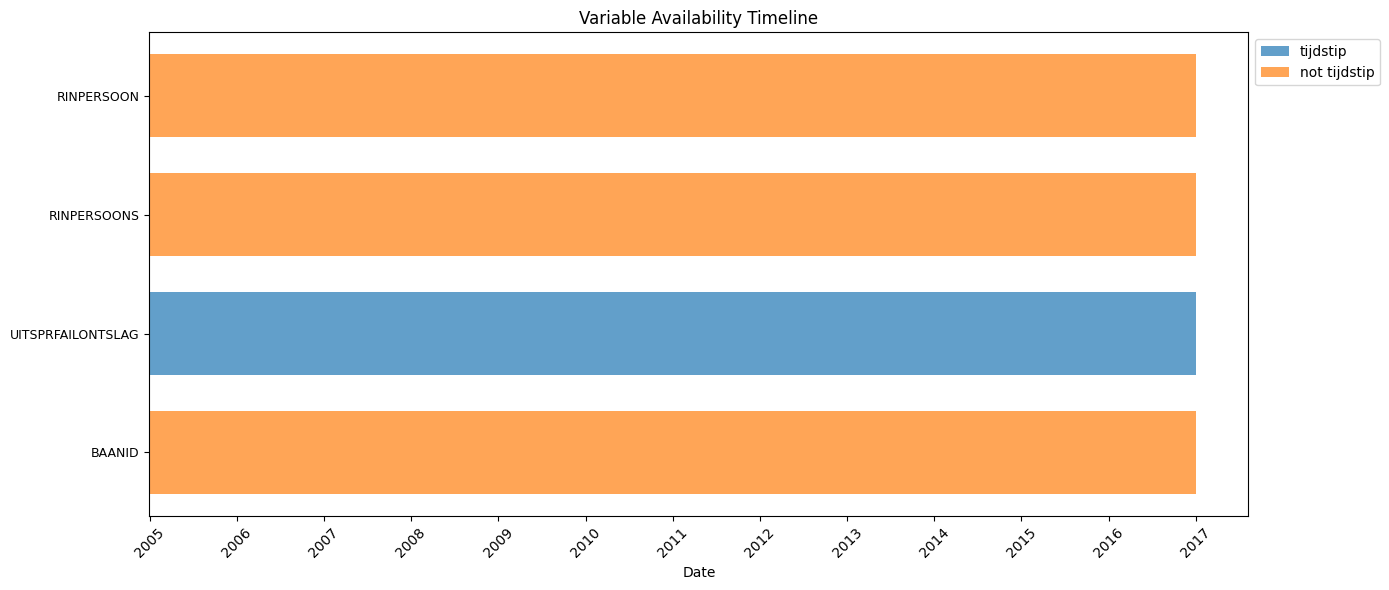

In [22]:
category_mapping_variables = {
    "tijdstip": "#1f77b4",  # Blue
    "not tijdstip": "#ff7f0e",  # Orange
}
dataset_title = "FAILONTSLAGTAB"
plot_df = vars_summarised.filter(pl.col("dataset_title") == dataset_title)
make_gantt_chart(
    plot_df,
    "column_type",
    "variable_name",
    category_mapping=category_mapping_variables,
    title="Variable Availability Timeline",
)

## Other queries

In [23]:
con.sql("""
select variable_name
    , count(distinct alt_title) as n_datasets
    from kg_variables
    join (
        select *
        from kg_datasets
        where lower(title) not like '%enquête%'
    )
    using(dataset_id)
    group by variable_name
    order by n_datasets desc;
""")

┌─────────────────────────┬────────────┐
│      variable_name      │ n_datasets │
│         varchar         │   int64    │
├─────────────────────────┼────────────┤
│ RINPERSOON              │        333 │
│ RINPERSOONS             │        327 │
│ IKVID                   │         11 │
│ GGZINSTELLING           │          7 │
│ GGZLOCATIE              │          7 │
│ OPLNR                   │          6 │
│ BRIN                    │          6 │
│ RINPERSOONSRELATIE      │          5 │
│ Prov                    │          5 │
│ RINPERSOONRELATIE       │          5 │
│      ·                  │          · │
│      ·                  │          · │
│      ·                  │          · │
│ AndrSrtBedr2            │          1 │
│ SILVRGTNDNODIG08        │          1 │
│ OpWoonwagencentrum31Dec │          1 │
│ OngwGedr2_d             │          1 │
│ AMREGIOWERK             │          1 │
│ BeroepExp_a             │          1 │
│ Opl_a                   │          1 │
│ Startgewicht  

In [24]:
con.sql("""
select variable_name
    , alt_title
    , title from kg_variables
join kg_datasets
using(dataset_id)
where variable_name = 'BAANID';
""")

┌───────────────┬──────────────────┬─────────────────────────────────────────────────────┐
│ variable_name │    alt_title     │                        title                        │
│    varchar    │     varchar      │                       varchar                       │
├───────────────┼──────────────────┼─────────────────────────────────────────────────────┤
│ BAANID        │ GEMSTPLAATSBUS   │ Gemeentecode Standplaats                            │
│ BAANID        │ BAANKENMERKENBUS │ Kwalitatieve kenmerken van banen van werknemers     │
│ BAANID        │ BAANSOMMENTAB    │ Kwantitatieve jaargegevens van banen van werknemers │
│ BAANID        │ FAILONTSLAGTAB   │ Baanbeëindigingen wegens faillissement              │
│ BAANID        │ GEMSTPLAATSBUS   │ Gemeentecode Standplaats                            │
│ BAANID        │ BAANKENMERKENBUS │ Kwalitatieve kenmerken van banen van werknemers     │
│ BAANID        │ BAANSOMMENTAB    │ Kwantitatieve jaargegevens van banen van werknemers │

It seems these two datasets cover the same thing? 
- can the KG tell use that??
- we could do a similarity search on the dataset title?

In [25]:
con.sql("""
select alt_title
    , is_frequency_dataset
    , is_tijdstip_dataset
    , valid_from
    , valid_until
    , title
from kg_datasets
where alt_title like '%FAIL%';
""")

┌────────────────┬──────────────────────┬─────────────────────┬────────────┬─────────────┬─────────────────────────────────────────┐
│   alt_title    │ is_frequency_dataset │ is_tijdstip_dataset │ valid_from │ valid_until │                  title                  │
│    varchar     │       boolean        │       boolean       │    date    │    date     │                 varchar                 │
├────────────────┼──────────────────────┼─────────────────────┼────────────┼─────────────┼─────────────────────────────────────────┤
│ FAILONTSLAGTAB │ true                 │ true                │ 1999-01-01 │ 2017-01-01  │ Baanbeëindigingen wegens faillissement  │
│ FAILONTTAB     │ true                 │ true                │ 2015-01-01 │ NULL        │ Werknemers ontslagen door faillissement │
└────────────────┴──────────────────────┴─────────────────────┴────────────┴─────────────┴─────────────────────────────────────────┘

In [26]:
con.sql("""
select alt_title, variable_name, label_
from kg_variables
inner join (
    select dataset_id, alt_title
    from kg_datasets
    where alt_title like '%FAIL%'
) using(dataset_id)
order by alt_title
""")

┌────────────────┬───────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│   alt_title    │   variable_name   │                                                     label_                                                     │
│    varchar     │      varchar      │                                                    varchar                                                     │
├────────────────┼───────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ FAILONTSLAGTAB │ RINPERSOON        │ Samen met RINPERSOONS identificeert dit nummer de persoon                                                      │
│ FAILONTSLAGTAB │ RINPERSOONS       │ Samen met RINPERSOON identificeert dit nummer de persoon                                                       │
│ FAILONTSLAGTAB │ UITSPRFAILONTSLAG │ Datum uitspraak faillissement van bedrijven met b

In [27]:
con.sql("""
select alt_title, valid_from, valid_until, title
from kg_datasets
where lower(title) like '%werkloos%'
order by alt_title
""")

┌───────────────────────┬────────────┬─────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│       alt_title       │ valid_from │ valid_until │                                                   title                                                    │
│        varchar        │    date    │    date     │                                                  varchar                                                   │
├───────────────────────┼────────────┼─────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ MICWWPERSOONBUS       │ 1999-01-01 │ 2017-01-01  │ Personen met een Werkloosheidswet (WW)-uitkering                                                           │
│ SECMWERKLMNDBEDRAGBUS │ 1999-01-01 │ NULL        │ Personen met een werkloosheidsuitkering in de verslagmaand                                                 │
│ SIRWWPERSOONBUS       │ 20

In [28]:
con.sql("""
select count(distinct dataset_id) as n_datasets,
    variable_name
from kg_variables
where variable_name like '%RINPERSOON%'
group by variable_name
order by n_datasets desc
""")

┌────────────┬─────────────────────────┐
│ n_datasets │      variable_name      │
│   int64    │         varchar         │
├────────────┼─────────────────────────┤
│        572 │ RINPERSOON              │
│        558 │ RINPERSOONS             │
│          5 │ RINPERSOONSOrigineel    │
│          5 │ RINPERSOONRELATIE       │
│          5 │ RINPERSOONSRELATIE      │
│          2 │ RINPERSOONKERN          │
│          2 │ RINPERSOONSOUD          │
│          2 │ RINPERSOONPARTNERRKT    │
│          2 │ RINPERSOON2             │
│          2 │ RINPERSOONONTVANGERRKT  │
│          · │      ·                  │
│          · │      ·                  │
│          · │      ·                  │
│          1 │ RINPERSOONpa            │
│          1 │ RINPERSOONSVERBINTENISP │
│          1 │ RINPERSOONP             │
│          1 │ RINPERSOONVTV           │
│          1 │ RINPERSOONSP            │
│          1 │ RINPERSOONS1PARTNER     │
│          1 │ RINPERSOONSMa           │
│          1 │ R